In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (update path if needed)
df = pd.read_excel(r"C:\Users\jooph\Downloads\ABC Company.xlsx")

df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [4]:
df.tail()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
453,Shelvin Mack,Utah Jazz,8,PG,26,2023-03-06 00:00:00,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,2023-01-06 00:00:00,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,2023-03-07 00:00:00,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0
457,Priyanka,Utah Jazz,34,C,25,2023-03-07 00:00:00,231,Kansas,947276.0


In [6]:
df.shape

(458, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [10]:
df.describe()

,Number,Age,Weight,Salary
count,458.000000,458.000000,458.000000,4.470000e+02
mean,17.713974,26.934498,221.543668,4.833970e+06
std,15.966837,4.400128,26.343200,5.226620e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.025210e+06
50%,13.000000,26.000000,220.000000,2.836186e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


In [11]:
df.describe(include='object')

,Name,Team,Position,Height,College
count,458,458,458,458,374
unique,458,30,5,18,118
top,Priyanka,New Orleans Pelicans,SG,2023-09-06 00:00:00,Kentucky
freq,1,19,102,59,22


In [12]:
df.describe(include='all')

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
count,458,458,458.000000,458,458.000000,458,458.000000,374,4.470000e+02
unique,458,30,NaN,5,NaN,18,NaN,118,NaN
top,Priyanka,New Orleans Pelicans,NaN,SG,NaN,2023-09-06 00:00:00,NaN,Kentucky,NaN
freq,1,19,NaN,102,NaN,59,NaN,22,NaN
mean,NaN,NaN,17.713974,NaN,26.934498,NaN,221.543668,NaN,4.833970e+06
std,NaN,NaN,15.966837,NaN,4.400128,NaN,26.343200,NaN,5.226620e+06
min,NaN,NaN,0.000000,NaN,19.000000,NaN,161.000000,NaN,3.088800e+04
25%,NaN,NaN,5.000000,NaN,24.000000,NaN,200.000000,NaN,1.025210e+06
50%,NaN,NaN,13.000000,NaN,26.000000,NaN,220.000000,NaN,2.836186e+06
75%,NaN,NaN,25.000000,NaN,30.000000,NaN,240.000000,NaN,6.500000e+06


In [13]:
df.columns

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')

In [14]:
df.nunique()

Name        458
Team         30
Number       53
Position      5
Age          22
Height       18
Weight       87
College     118
Salary      309
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.isnull().sum()

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [19]:
df.dtypes

Name         object
Team         object
Number        int64
Position     object
Age           int64
Height       object
Weight        int64
College      object
Salary      float64
dtype: object

### Preprocessing:  
● Correct the data in the "height" column by replacing it with random 
numbers between 150 and 180. Ensure data consistency and integrity 
before proceeding with analysis. (1 mark)  

In [20]:
df['height'] = np.random.randint(150, 181, size=len(df))
#You generate realistic heights (150–180 cm)
#size=len(df) ensures every row gets a value

In [21]:
df['height'].describe()

count    458.000000
mean     165.351528
std        8.687424
min      150.000000
25%      158.000000
50%      165.000000
75%      173.000000
max      180.000000
Name: height, dtype: float64

### Analysis Tasks:  
● Determine the distribution of employees across each team and calculate 
the percentage split relative to the total number of employees. (2 marks)

In [25]:
team_dist = df['Team'].value_counts()
team_dist

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64

In [27]:
team_percent = df['Team'].value_counts(normalize=True) * 100 
#Counts how many employees are in each team
#Percentage shows proportion relative to total employees
#Helps answer: Which team has more employees?
team_percent

Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
Milwaukee Bucks           3.493450
New York Knicks           3.493450
Boston Celtics            3.275109
Los Angeles Clippers      3.275109
Los Angeles Lakers        3.275109
Phoenix Suns              3.275109
Sacramento Kings          3.275109
Brooklyn Nets             3.275109
Philadelphia 76ers        3.275109
Toronto Raptors           3.275109
Golden State Warriors     3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Houston Rockets           3.275109
San Antonio Spurs         3.275109
Atlanta Hawks             3.275109
Dallas Mavericks          3.275109
Charlotte Hornets         3.275109
Miami Heat                3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Orlando Magic  

### Visualization:

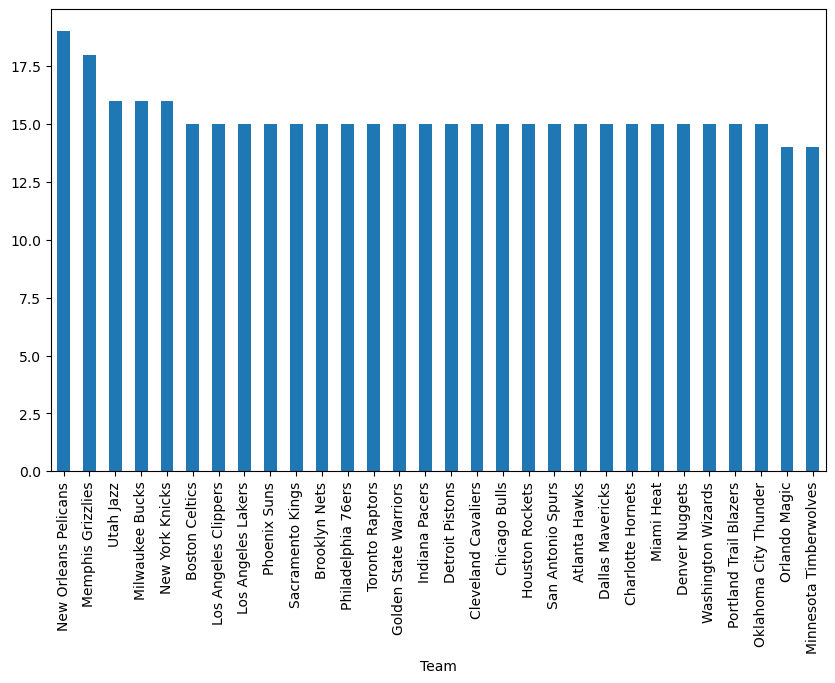

In [40]:
plt.figure(figsize=(10,6))
df['Team'].value_counts().plot(kind='bar') #Bar chart makes comparison easy.
plt.show()

### Analysis Tasks: 
● Segregate employees based on their positions within the company. (2 
marks)  


In [33]:
df['Position'].value_counts()

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64

### Visualization:

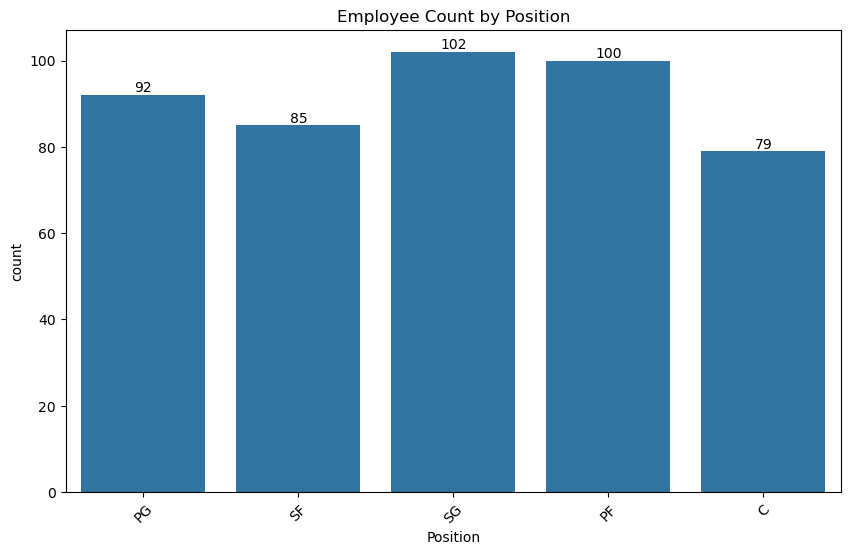

In [36]:
plt.figure(figsize=(10,6))

ax = sns.countplot(x='Position', data=df)

# Add values on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.title("Employee Count by Position")
plt.show()

### Analysis Tasks:
● Identify the predominant age group among employees. (2 marks)  

In [42]:
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '30-40', '40-50', '50-60']

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df['age_group'].value_counts())

age_group
20-30    346
30-40     91
40-50      0
50-60      0
Name: count, dtype: int64


### Visualization:

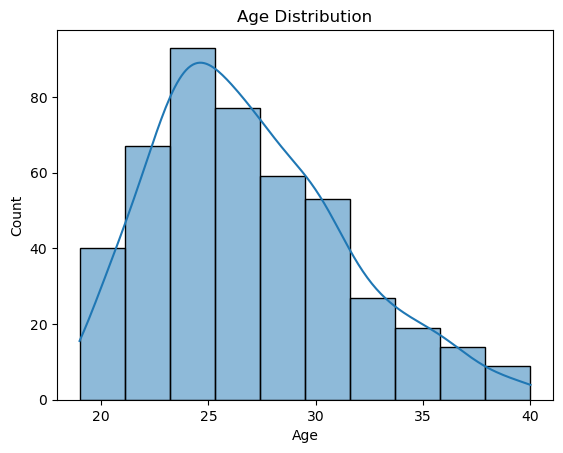

In [43]:
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

### Analysis Tasks:
● Discover which team and position have the highest salary expenditure. (2 
marks)  

In [48]:
df.groupby('Team')['Salary'].sum()
df.groupby('Position')['Salary'].sum()
#Adds total salary paid per team and position
#Identifies where company spends the most money

Position
C     466377332.0
PF    442560850.0
PG    446848971.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64

### Analysis Tasks:
● Investigate if there's any correlation between age and salary, and 
represent it visually. (2 marks)  

In [54]:
correlation = df['Age'].corr(df['Salary'])
print("Correlation between Age and Salary:", correlation)

Correlation between Age and Salary: 0.21400941226570974


### Visualization:

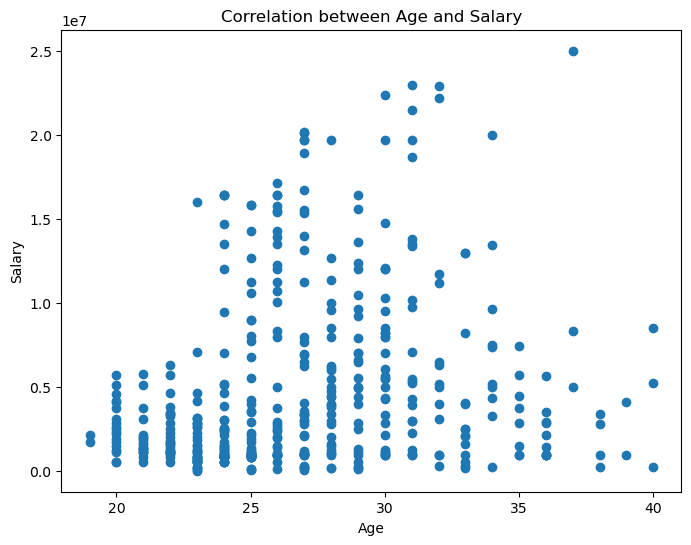

In [56]:
plt.figure(figsize=(8,6))

plt.scatter(df['Age'], df['Salary'])

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Correlation between Age and Salary")

plt.show()

### Data Analysis
● Data Story: Provide insights gained from the analysis, highlighting key trends, patterns, and correlations within the dataset. 



1. Team Distribution
	•	The number of players/employees across teams is almost uniform.
	•	No team shows extreme dominance or shortage in count.
Insight:
This indicates a balanced dataset, meaning comparisons across teams are reliable and not biased by unequal data representation

2. Position-wise Distribution
	•	Shooting Guards (SG) and Power Forwards (PF) have the highest counts.
	•	Centers (C) have the lowest count.
	•	Other positions like PG and SF fall in between.
 Insight:
There is a slight imbalance in role distribution, suggesting:
	•	Some roles are more in demand or commonly assigned.
	•	Certain positions (like Center) are more specialized and limited.

3. Age Distribution
	•	Most individuals fall within the 22–30 age range.
	•	The peak occurs around mid-20s (24–26).
	•	Very few individuals are above 35+.
 Insight:
	•	The dataset represents a young workforce/player base.
	•	Indicates early- to mid-career individuals dominate.
	•	Slight right-skew suggests fewer older individuals.


4.  Correlation between Age and Salary
	•	Correlation coefficient ≈ 0.21 → weak positive correlation.
	•	Scatter plot shows high variability in salary at all ages.

 Insights:
	•	Salary does not strongly depend on age.
	•	Individuals of similar age earn significantly different salaries.
	•	Some younger individuals earn high salaries → likely high performers or skilled roles.

5.  Salary Distribution Pattern (from scatter observation)
	•	Salary spread is wide across all age groups.
	•	No clear linear trend.
 Insight:
Salary is likely influenced by:
	•	Position/role
	•	Skill level
	•	Performance
	•	Experience (not strictly age)


 Overall Patterns & Trends

Balanced Structure
	•	Teams are evenly distributed → good data quality.

Role Imbalance
	•	Some positions dominate (SG, PF), others are scarce (C).

 Young Population
	•	Majority are in early career stages.

Weak Age–Salary Relationship
	•	Age alone is not a strong predictor of salary.

High Salary Variability
	•	Suggests a performance-based or role-based pay system rather than age-based.

Final Conclusion

The dataset reveals a young, well-balanced population across teams, with moderate variation in role distribution.
A key finding is that salary is not strongly correlated with age, indicating that compensation is likely driven by skills, role, or performance rather than seniority alone.